In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def plot(key, title):
    api = wandb.Api()
    run = api.run(f"madoka-hong-kong-university-of-science-and-technology/roll_examples/runs/{key}")
    history = run.history(stream="systemMetrics")

    ngpus = 8
    plt.figure(figsize=(12, 2.5))
    gmem_allocated = [[] for _ in range(ngpus)]
    print(len(history))
    for step in range(len(history)):
        for gid in range(ngpus):
            if f'system.gpu.{gid}.memoryAllocated' in history[step]:
                gmem_allocated[gid].append(history[step][f'system.gpu.{gid}.memoryAllocated'])
            # else:
            #     gmem_allocated[gid].append(0)

    for gid in range(ngpus):
        gmem_allocated[gid] = np.array(gmem_allocated[gid])
        plt.plot(gmem_allocated[gid], label=f"{gid}")
    plt.legend(ncols=8)
    plt.title(title)

    # print(len(gmem_allocated[0]))
    gen_util = len(gmem_allocated[0][np.where(gmem_allocated[0] > 10)]) / len(gmem_allocated[0])
    train_util = len(gmem_allocated[7][np.where(gmem_allocated[7] > 10)]) / len(gmem_allocated[7])
    print(f"Gen util: {gen_util}, Train util: {train_util}")

wandb: WARNING Unable to load pandas, call history with pandas=False


518
Gen util: 0.40540540540540543, Train util: 0.5135135135135135


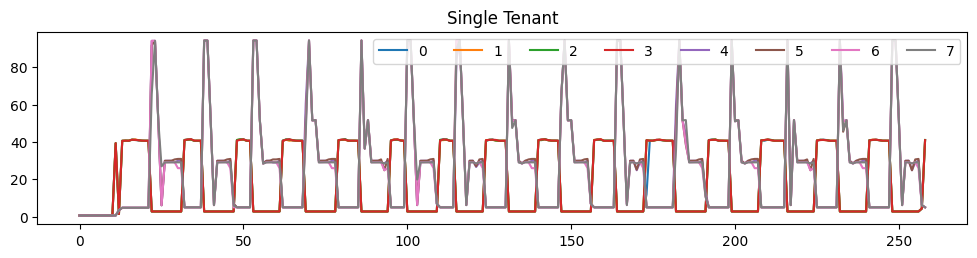

In [3]:
plot("htl8kcje", "Single Tenant")

wandb: WARNING Unable to load pandas, call history with pandas=False


864
Gen util: 0.7245370370370371, Train util: 0.9259259259259259


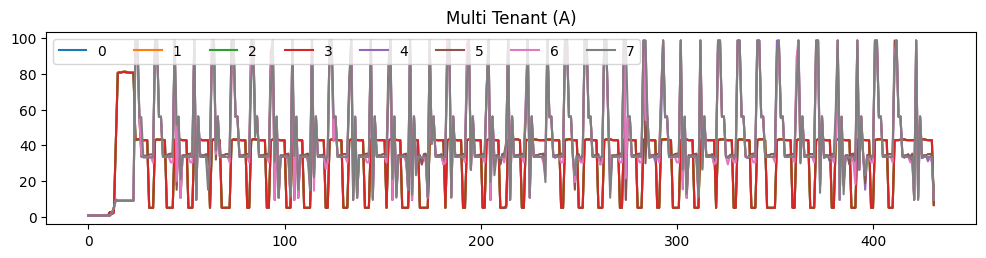

In [4]:
plot("4sddtlf8", "Multi Tenant (A)")

wandb: WARNING Unable to load pandas, call history with pandas=False


864
Gen util: 0.7245370370370371, Train util: 0.9305555555555556


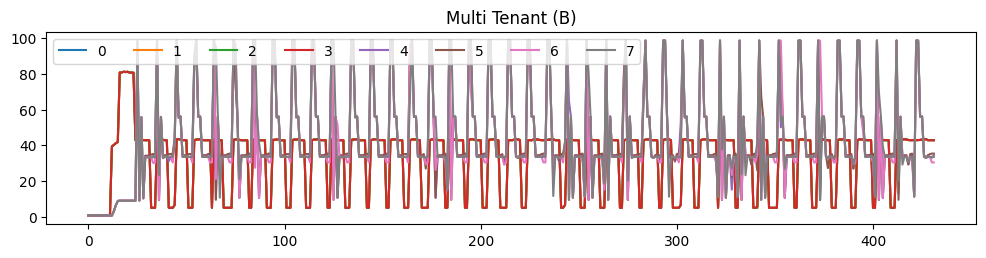

In [5]:
plot("9hmp3d4z", "Multi Tenant (B)")

wandb: WARNING Unable to load pandas, call history with pandas=False


920
Gen util: 0.9608695652173913, Train util: 0.9369565217391305


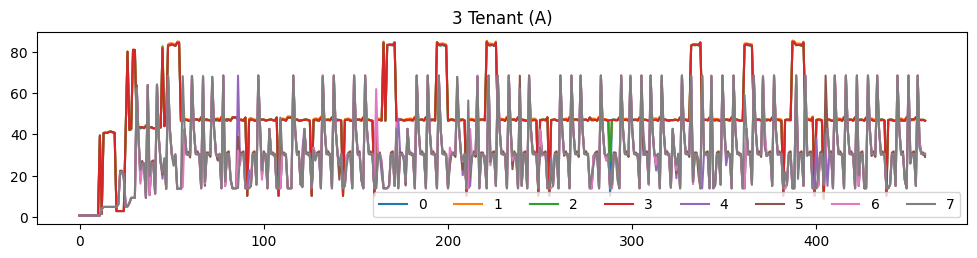

In [6]:
plot("mk0yt45n", "3 Tenant (A)")

wandb: WARNING Unable to load pandas, call history with pandas=False


890
Gen util: 0.9865168539325843, Train util: 0.9707865168539326


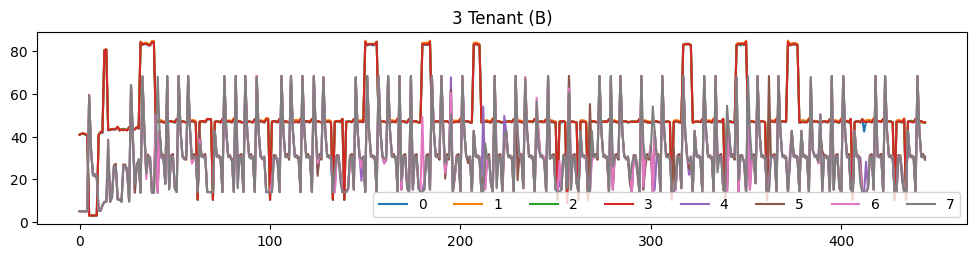

In [8]:
plot("uu07nofv", "3 Tenant (B)")

wandb: WARNING Unable to load pandas, call history with pandas=False


852
Gen util: 0.9976525821596244, Train util: 0.9929577464788732


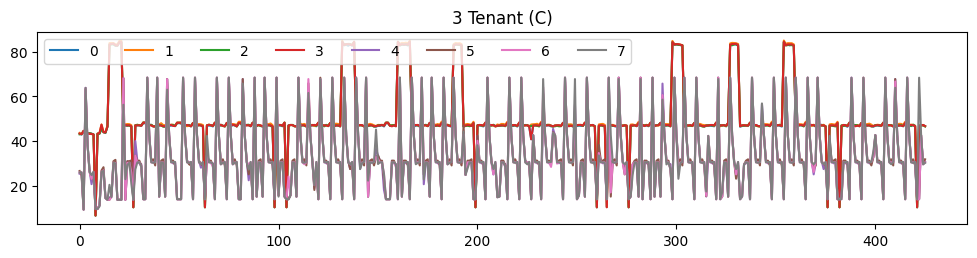

In [9]:
plot("owft1alp", "3 Tenant (C)")